# Chains in LangChain

* LLMChain (Please see summarization file from krish naik folder.)
* Sequential Chains
  * SimpleSequentialChain
  * SequentialChain
* Router Chain

1. LLMChain
The most basic chain, directly feeding a prompt to an LLM and returning its output.
Often used as a building block for more complex chains.
2. Sequential Chains
Execute multiple steps sequentially, passing the output of one step as input to the next.
Useful for multi-step tasks like summarization followed by question answering.
3. Router Chains
Directs input to different subchains based on specific conditions or criteria.
Ideal for handling diverse input types or routing tasks to specialized models.
4. Combine Documents Chains
Specifically designed for processing and combining multiple documents before feeding them to an LLM.
Useful for tasks like document summarization or question answering over multiple documents.
5. Utility Chains
Provide pre-built functionalities like document loaders, text splitters, or search.
Often used as components within larger chains.

Chain Types :-------

chain_type="stuff" parameter indicates that the chain will use a "stuffing" approach to combine documents into a single prompt before sending it to the LLM. This means all relevant documents are concatenated together and passed as a single input to the language model.

chain_type="map_reduce": This approach splits documents into smaller chunks, processes them individually, and then combines the results. MOstly used in summarization task.

chain_type="refine": This method iteratively refines the answer by providing feedback to the LLM.

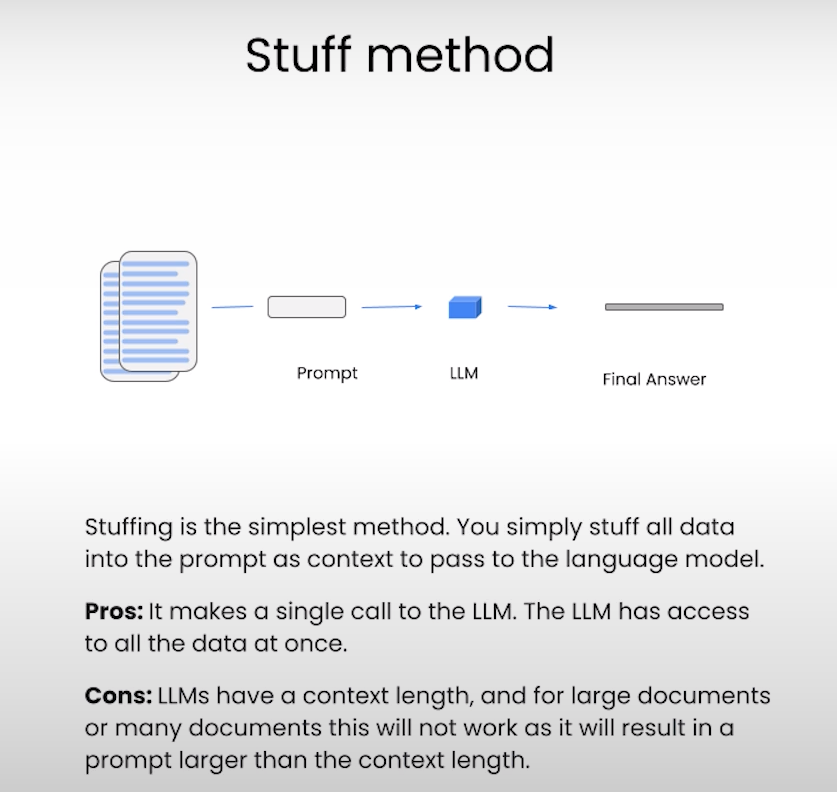
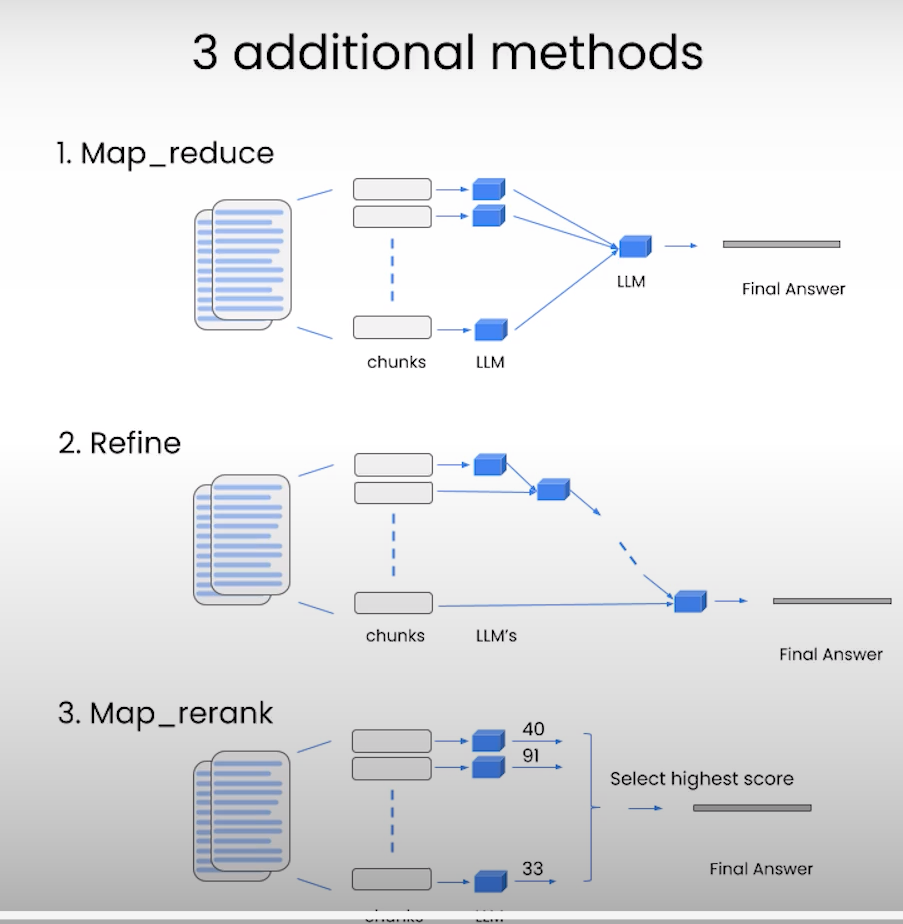
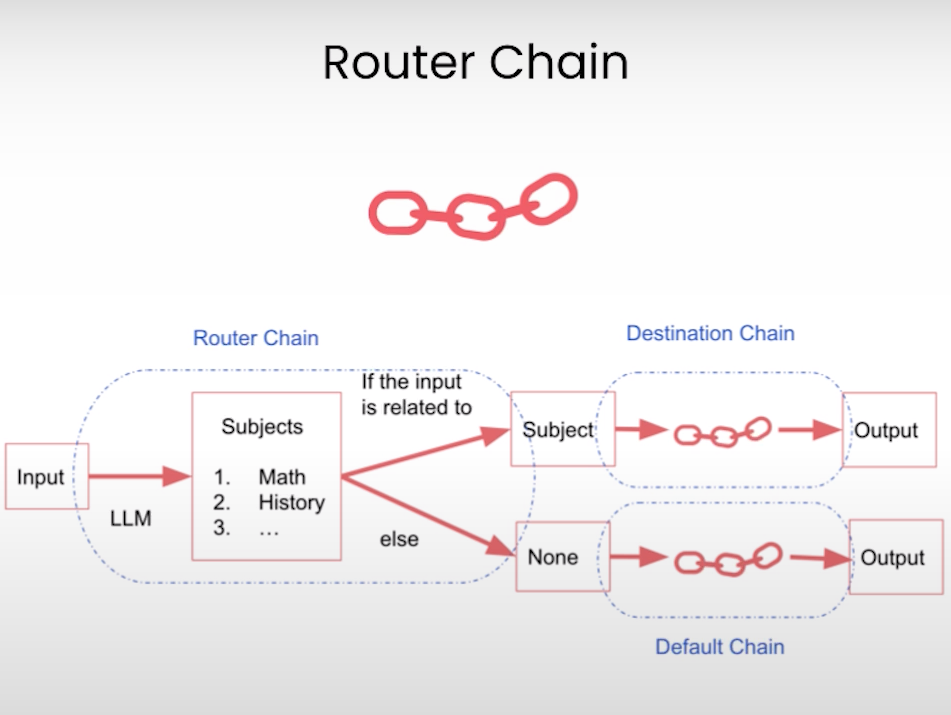

In [43]:
import os
from dotenv import load_dotenv

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

from langchain_community.embeddings import HuggingFaceBgeEmbeddings
from langchain.prompts import PromptTemplate
from langchain_community.llms.huggingface_pipeline import HuggingFacePipeline
from langchain.chains import RetrievalQA

# from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline

from huggingface_hub import login
import torch



In [44]:
load_dotenv()

HF_Token = os.environ['HUGGINGFACEHUB_API_TOKEN']

login(token=HF_Token)

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
Your token has been saved to C:\Users\riman\.cache\huggingface\token
Login successful


In [45]:
from langchain_community.llms import HuggingFaceHub

llm=HuggingFaceHub(
    repo_id="mistralai/Mistral-7B-Instruct-v0.3", #mistralai/Mistral-7B-v0.1, meta-llama/Llama-2-7b-chat-hf
    model_kwargs={"temperature":0.1,"max_length":5000}

)
query="What is 1+1?"
response = llm.invoke(query)

response

'What is 1+1?\n\nThe answer to this question is 2. This is a basic arithmetic operation that most people learn in early childhood. However, the question itself can be interpreted in different ways, leading to different answers. For example, in the context of set theory, the union of two sets is the set that contains all the elements of the original sets. In this case, the answer would be the set {1,2}. In the context of computer programming, the answer could be the binary'

In [49]:
from langchain.chains import LLMChain
from langchain.chains import SimpleSequentialChain
from langchain.chains import SequentialChain

# prompt template 1
first_prompt = PromptTemplate.from_template(
    "What is the best name to describe \
    a company that makes {product}?"
)

# Chain 1
chain_one = LLMChain(llm=llm, prompt=first_prompt)
product = "Queen Size Sheet Set"
chain_one.run(product)

'What is the best name to describe     a company that makes Queen Size Sheet Set?\n\nA Queen Size Sheet Set Manufacturing Company would be an appropriate name for a company that specializes in producing Queen Size Sheet Sets. This name clearly communicates the product the company produces and the nature of its business.\n\nHere are some variations of the name:\n\n1. Queen Size Sheets Co.\n2. Queen Size Linens Manufacturing\n3. Royal Bedding Co.\n4. Queen Size Sheet Set Producers\n5. Queen Size'

In [65]:
second_prompt = PromptTemplate.from_template(
    "Write a 20 words description for the following \
    company:{company_name}"
)
company = "Alphabate"
# chain 2
chain_two = LLMChain(llm=llm, prompt=second_prompt)

overall_simple_chain = SimpleSequentialChain(chains=[chain_one, chain_two],
                                             verbose=True
                                            )

overall_simple_chain.run(product)

# overall_simple_chain.run({'input':product})



> Entering new SimpleSequentialChain chain...
Translate the following review to english:

Queen Size Sheet Set:

"This queen size sheet set is a great addition to any bed. The quality of the materials is excellent, and the colors are vibrant and attractive. The set includes a fitted sheet, a flat sheet, and two pillowcases. The fitted sheet fits perfectly on my queen size mattress, and the flat sheet is large enough to cover the entire bed. The pillowcases are a nice touch, and they fit my standard size pillows perfectly. The set is easy to wash and dry
Write a 20 words description for the following     company:Translate the following review to english:

Queen Size Sheet Set:

"This queen size sheet set is a great addition to any bed. The quality of the materials is excellent, and the colors are vibrant and attractive. The set includes a fitted sheet, a flat sheet, and two pillowcases. The fitted sheet fits perfectly on my queen size mattress, and the flat sheet is large enough to co

'Write a 20 words description for the following     company:Translate the following review to english:\n\nQueen Size Sheet Set:\n\n"This queen size sheet set is a great addition to any bed. The quality of the materials is excellent, and the colors are vibrant and attractive. The set includes a fitted sheet, a flat sheet, and two pillowcases. The fitted sheet fits perfectly on my queen size mattress, and the flat sheet is large enough to cover the entire bed. The pillowcases are a nice touch, and they fit my standard size pillows perfectly. The set is easy to wash and dry, and it has held up well after multiple washes. I highly recommend this queen size sheet set to anyone looking for a high-quality, affordable option for their bed."\n\nCompany Description:\n\n"Affordable, high-quality bedding solutions provider."\n\nReview Translation:\n\n"This queen size sheet set is a fantastic addition to any bed. The quality of the materials is exceptional, and the colors are bright and appealing. 

In [51]:
import pandas as pd

df =pd.read_csv(r"documents/chain_data.csv")

# df.head() 

# prompt template 1: translate to english
first_prompt = PromptTemplate.from_template(
    "Translate the following review to english:"
    "\n\n{Review}"
)
# chain 1: input= Review and output= English_Review
chain_one = LLMChain(llm=llm, prompt=first_prompt, 
                     output_key="English_Review"
                    )

second_prompt = PromptTemplate.from_template(
    "Can you summarize the following review in 1 sentence:"
    "\n\n{English_Review}"
)
# chain 2: input= English_Review and output= summary
chain_two = LLMChain(llm=llm, prompt=second_prompt, 
                     output_key="summary"
                    )


# prompt template 3: translate to english
third_prompt = PromptTemplate.from_template(
    "What language is the following review:\n\n{Review}"
)
# chain 3: input= Review and output= language
chain_three = LLMChain(llm=llm, prompt=third_prompt,
                       output_key="language"
                      )



# prompt template 4: follow up message
fourth_prompt = PromptTemplate.from_template(
    "Write a follow up response to the following "
    "summary in the specified language:"
    "\n\nSummary: {summary}\n\nLanguage: {language}"
)
# chain 4: input= summary, language and output= followup_message
chain_four = LLMChain(llm=llm, prompt=fourth_prompt,
                      output_key="followup_message"
                     )


# overall_chain: input= Review 
# and output= English_Review,summary, followup_message
overall_chain = SequentialChain(
    chains=[chain_one, chain_two, chain_three, chain_four],
    input_variables=["Review"],
    output_variables=["English_Review", "summary","followup_message"],
    verbose=True
)

review = df.Review[3]
overall_chain(review)

c:\Users\riman\VSCode\GenAI_Projects\GenAI\gen_env\lib\site-packages\langchain_core\_api\deprecation.py:119: LangChainDeprecationWarning: The method `Chain.__call__` was deprecated in langchain 0.1.0 and will be removed in 0.3.0. Use invoke instead.
  warn_deprecated(




> Entering new SequentialChain chain...

> Finished chain.


{'Review': 'This is the best throw pillow fillers on Amazo',
 'English_Review': 'Translate the following review to english:\n\nThis is the best throw pillow fillers on Amazo. I have tried many different brands and this one is by far the best. It is very soft and fluffy, and it holds its shape well. I have had it for several months now and it has not lost any of its fluffiness. I would highly recommend this product to anyone looking for a good throw pillow filler.\n\nThis is the best throw pillow filler on Amazon. I have tried various brands, and this one is by far the best. It is very soft',
 'summary': 'Can you summarize the following review in 1 sentence:\n\nTranslate the following review to english:\n\nThis is the best throw pillow fillers on Amazo. I have tried many different brands and this one is by far the best. It is very soft and fluffy, and it holds its shape well. I have had it for several months now and it has not lost any of its fluffiness. I would highly recommend this pr

## Router Chain

In [52]:
physics_template = """You are a very smart physics professor. \
You are great at answering questions about physics in a concise\
and easy to understand manner. \
When you don't know the answer to a question you admit\
that you don't know.

Here is a question:
{input}"""


math_template = """You are a very good mathematician. \
You are great at answering math questions. \
You are so good because you are able to break down \
hard problems into their component parts, 
answer the component parts, and then put them together\
to answer the broader question.

Here is a question:
{input}"""

history_template = """You are a very good historian. \
You have an excellent knowledge of and understanding of people,\
events and contexts from a range of historical periods. \
You have the ability to think, reflect, debate, discuss and \
evaluate the past. You have a respect for historical evidence\
and the ability to make use of it to support your explanations \
and judgements.

Here is a question:
{input}"""


computerscience_template = """ You are a successful computer scientist.\
You have a passion for creativity, collaboration,\
forward-thinking, confidence, strong problem-solving capabilities,\
understanding of theories and algorithms, and excellent communication \
skills. You are great at answering coding questions. \
You are so good because you know how to solve a problem by \
describing the solution in imperative steps \
that a machine can easily interpret and you know how to \
choose a solution that has a good balance between \
time complexity and space complexity. 

Here is a question:
{input}"""

In [53]:
prompt_infos = [
    {
        "name": "physics", 
        "description": "Good for answering questions about physics", 
        "prompt_template": physics_template
    },
    {
        "name": "math", 
        "description": "Good for answering math questions", 
        "prompt_template": math_template
    },
    {
        "name": "History", 
        "description": "Good for answering history questions", 
        "prompt_template": history_template
    },
    {
        "name": "computer science", 
        "description": "Good for answering computer science questions", 
        "prompt_template": computerscience_template
    }
]

In [54]:
from langchain.chains.router import MultiPromptChain
from langchain.chains.router.llm_router import LLMRouterChain,RouterOutputParser

In [55]:

destination_chains = {}
for p_info in prompt_infos:
    name = p_info["name"]
    prompt_template = p_info["prompt_template"]
    prompt = PromptTemplate.from_template(template=prompt_template)
    chain = LLMChain(llm=llm, prompt=prompt)
    destination_chains[name] = chain  
    
destinations = [f"{p['name']}: {p['description']}" for p in prompt_infos]
destinations_str = "\n".join(destinations)

In [56]:
default_prompt = PromptTemplate.from_template("{input}")
default_chain = LLMChain(llm=llm, prompt=default_prompt)

In [57]:
MULTI_PROMPT_ROUTER_TEMPLATE = """Given a raw text input to a \
language model select the model prompt best suited for the input. \
You will be given the names of the available prompts and a \
description of what the prompt is best suited for. \
You may also revise the original input if you think that revising\
it will ultimately lead to a better response from the language model.

<< FORMATTING >>
Return a markdown code snippet with a JSON object formatted to look like:
```json
{{{{
    "destination": string \ name of the prompt to use or "DEFAULT"
    "next_inputs": string \ a potentially modified version of the original input
}}}}
```

REMEMBER: "destination" MUST be one of the candidate prompt \
names specified below OR it can be "DEFAULT" if the input is not\
well suited for any of the candidate prompts.
REMEMBER: "next_inputs" can just be the original input \
if you don't think any modifications are needed.

<< CANDIDATE PROMPTS >>
{destinations}

<< INPUT >>
{{input}}

<< OUTPUT (remember to include the ```json)>>"""

In [58]:
router_template = MULTI_PROMPT_ROUTER_TEMPLATE.format(
    destinations=destinations_str
)
router_prompt = PromptTemplate(
    template=router_template,
    input_variables=["input"],
    output_parser=RouterOutputParser(),
)

router_chain = LLMRouterChain.from_llm(llm, router_prompt)

In [59]:
chain = MultiPromptChain(router_chain=router_chain, 
                         destination_chains=destination_chains, 
                         default_chain=default_chain, verbose=True
                        )

In [63]:
chain.run("What is black body radiation?")

In [62]:
chain.run("what is 2 + 2")

In [ ]:
chain.run("Why does every cell in our body contain DNA?")